<div class="alert alert-block alert-info">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Hola Balbina soy Santiago y hoy reviso tu proyecto. Guia rapida de colores:

Por favor no muevas, edites ni elimines mis comentarios. Empecemos! 🚀
</div>
<div class="alert alert-block alert-success">Verde: algo esta bien hecho.</div>
<div class="alert alert-block alert-warning">Amarillo: tip o recomendacion, no bloquea la aprobacion.</div>
<div class="alert alert-block alert-danger">Rojo: necesita correccion antes de aprobar.</div>


<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

El diagnostico de fechas (con buen detalle sobre que los 40 registros de 2026 comparten la misma fecha exacta) y la limpieza de `age`/`reg_date`, MAR, agregacion, merge, histogramas, boxplots e IQR estan bien resueltos. Pero encontre un problema importante que si necesita correccion antes de aprobar:

- **El insight ejecutivo describe cosas que no hiciste:** dice que se encontraron "valores nulos en `age` (aprox 10% de las filas)" - pero `age` no tiene nulos, tiene el sentinel `-999` en 1.38% de los registros (55 filas), como tu mismo diagnosticaste correctamente en la seccion 2.2. Tambien dice que "se detectaron duplicados en `user_id` y registros con duracion de llamada = 0, se eliminaron" - no encontre en ningun lado del notebook una verificacion de duplicados en `user_id` ni un filtro que elimine registros con `duration = 0`. Esta seccion debe describir lo que realmente hiciste, no otro analisis.

Tambien note que el `execution_count` de todo el notebook esta muy desordenado (saltos de 3,4,3,4,5... y luego 21,23,6,12,9,10...), señal de que se ejecuto fuera de orden muchas veces - te recomiendo hacer un Restart & Run All antes de la proxima entrega para confirmar que todo corre limpio de principio a fin.

Con la correccion del insight ejecutivo, el proyecto queda listo para aprobar.

</div>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt # importar librerías

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [3]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()  # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()  # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen calculo de nulos para `users` y `usage` por separado.
</div>

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
users[['user_id', 'age']].describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen diagnostico, identificando correctamente el `-999` en `age` y su efecto inflando la desviacion estandar.
</div>

- La columna `user_id`... Haz doble clic en este bloque y escribe qué ves.
- Dataset `users`, columna `user_id`: 4000 registros sin nulos, rango de 10000 a 13999, sin valores atípicos, es un identificador secuencial limpio.

- La columna `age` ...
- Dataset `users`, columna `age`: 4000 registros, min -999.0 es un valor sentinel imposible que infla el std a 123.23, max 79.0 válido, mediana 47.0 y p75 63.0; se tratará el -999 como nulo y se imputará con la mediana.

In [13]:
usage.describe()# explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buena exploracion, con buena observacion sobre los nulos estructurales de `duration`/`length`.
</div>

- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Dataset 'usage',columna 'id' y 'user_id' : 40000 registros sin nulos, 'id' va con un min de 1 a 40000. media de 20000.5, en 'user_id' con un min de 10000 a 13999 .
- Las columnas 'duration' y 'lentgth': presentan nulos estructurales, la columna'duration'solo tiene 17924 registros,media 5.20min y max 120min. La columna 'lenght' tiene 22104 registros , media 52.12 caracteres y max 1490 caracteres. los nulos ocurren porque 'duration' son llamadas y 'length' son sms, son validos.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print (plans ['plan_name'].value_counts()) 
print (users ['city'].value_counts()) 
print (users ['plan'].value_counts())  # corrección 
 

Basico     1
Premium    1
Name: plan_name, dtype: int64
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Revisaste `plans['plan_name']` en vez de `users['plan']` para ver la distribucion del plan - aunque tu diagnostico de abajo llega a la conclusion correcta (2 planes, Basico y Premium), esta celda no muestra realmente la distribucion de `users['plan']`. Vale la pena corregir la referencia.
</div>

- La columna `city` (users): 7 valores únicos; incluye'?' con 96 registros (datos sucios), Bogotá con 808, Medellín con 616, Cali con 424.
- La columna `plan`(users) : 2 planes 'Basico' y 'premium'

In [15]:
# explorar columna categórica de usage
print (usage['type'].value_counts())

text    22092
call    17908
Name: type, dtype: int64


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buena exploracion y conexion con los nulos estructurales de duration/length.
</div>

- La columna `type` (usage): 2 valores 'call' 17908 y 'text' 22092; coinciden con los nullos estructurales de 'duration' y 'lenght'


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Tip para tu proximo proyecto: la rubrica tambien sugiere encapsular esta exploracion en una funcion reutilizable, por ejemplo `def valores_invalidos(df, columnas): ...`. No bloquea esta entrega.
</div>

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- ¿Qué acción tomarías?
- La columna user.city: valor ? detectado con 96 registros ; sentinel de error de captura. Acción reemplazar -> Nan y luego imputar con moda.
- La columna plans, usage.type : sin invalidos.Valores dentro del dominio esperado. Acción: no requier acción.
- La columna Type: 2 valores.tex 22092, call 17908. Coincide con nulos estructurales. Acción no requiere acción. Nulos estructurales,comportamiento esperado.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime (users['reg_date'],errors='coerce')
users['reg_date'].dtype
users.info()# completa el código

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime (usage['date'],errors='coerce')
usage['date'].dtype
users.info()# completa el código

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [18]:
users['reg_date'].dt.year.value_counts().sort_index()# Revisar los años presentes en `reg_date` de users



2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

In [19]:
users[users['reg_date'].dt.year == 2026]['reg_date'].sort_values()

40     2026-05-10
1736   2026-05-10
1737   2026-05-10
1862   2026-05-10
1880   2026-05-10
1896   2026-05-10
2055   2026-05-10
2093   2026-05-10
1722   2026-05-10
2111   2026-05-10
2184   2026-05-10
2200   2026-05-10
2235   2026-05-10
2307   2026-05-10
2475   2026-05-10
2743   2026-05-10
3035   2026-05-10
2162   2026-05-10
1679   2026-05-10
1627   2026-05-10
1314   2026-05-10
56     2026-05-10
60     2026-05-10
70     2026-05-10
248    2026-05-10
320    2026-05-10
326    2026-05-10
505    2026-05-10
527    2026-05-10
646    2026-05-10
885    2026-05-10
914    2026-05-10
948    2026-05-10
986    2026-05-10
1047   2026-05-10
1210   2026-05-10
1275   2026-05-10
1293   2026-05-10
3299   2026-05-10
3988   2026-05-10
Name: reg_date, dtype: datetime64[ns]

En la columna `reg_date´: se observa 4 años: 2022 (1314), 2023 (1316), 2024 (1330) y 2026 (40). Los 40 registros de 2026 corresponden todos a la misma fecha 2026-05-10, lo que indica un registro anómalo / masivo y no una distribución real de altas. Se debe tratar como outlier.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Excelente diagnostico - identificar que los 40 registros de 2026 comparten exactamente la misma fecha (2026-05-10) es una observacion muy util que no todos hacen.
</div>

In [20]:
usage['date'].dt.year.value_counts().sort_index()# Revisar los años presentes en `date` de usage


2024.0    39950
Name: date, dtype: int64

En la columna date de usage : se observa un único año: 2024 con 39,950 registros. No hay dispersión por años, todo el uso registrado corresponde a 2024. Basaremos el análisis en 2024, ya que es el único año con información de uso.
filtraremos los registros de reg_date de 2026 por ser atípicos.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- En la columna'reg_date' (users): aparecen años fuera de rango. Hay 40 registros en 2026 y todos con la misma fecha 2026-05-10. Al ser una fecha única y masiva, no es un alta real orgánica, es un dato anómalo de carga o prueba. 
- En la columna 'date' (usage): Todo está concentrado en 2024 (39,950 registros), lo cual es coherente para un análisis anual, pero hay que validar que sea consistente con reg_date.
- ¿Qué harías con ellas?
- En la columna reg_date (users) la acción es convertir los 40 valores con fecha 2026-05-10 a NaT (nulo de fecha) para no contaminar análisis futuros, además de documentar la incidencia. No se puede inferir la fecha real por city o plan_name al ser todos el mismo día y ser un lote masivo, por lo que lo más seguro es tratarlo como nulo.
- Para la columna 'date' (usage): No haría limpieza por año, porque no hay años imposibles. Solo confirmaría que la columna esté bien convertida a datetime (aparece como 2024.0 con punto, indica que era float) con pd.to_datetime().

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median() 
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Correcto - mediana calculada excluyendo el sentinel antes.
</div>

In [22]:
import numpy as np
users['city'] = users['city'].replace('?', np.nan) # Reemplazar ? por NA en city


users['city'].isna().sum()
users['city'].value_counts(dropna=False).head(10)# Verificar cambios


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Tu diagnostico de la seccion 2.2 decia "reemplazar -> NaN y luego imputar con moda", pero el codigo real solo reemplaza `"?"` por `np.nan` y no llega a imputar con la moda - lo cual, de hecho, es la decision correcta segun la rubrica (dejarlo como nulo, no imputar). Vale la pena actualizar el texto del diagnostico para que sea consistente con lo que realmente implementaste (que es lo correcto).
</div>

In [23]:
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT# Marcar fechas futuras como NA para reg_date


users['reg_date'].isna().sum()
print(users['reg_date'].isna().sum())
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())# Verificar cambios


40
2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


In [24]:
users['user_id'].duplicated().sum()

0

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Correcto - `reg_date` corregido filtrando exactamente el año 2026.
</div>

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())# Verificación MAR en usage (Missing At Random) para duration
pd.crosstab(usage['type'], usage['duration'].isna())

duration,False,True
type,,
call,17908,0
text,16,22076


In [26]:
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())
pd.crosstab(usage['type'], usage['length'].isna())# Verificación MAR en usage (Missing At Random) para length


length,False,True
type,,
call,12,17896
text,22092,0


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Excelente verificacion MAR, con `groupby` y `crosstab` como doble verificacion, y una explicacion muy clara.
</div>

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Diagnóstico de nulos en duration y length:Después de verificar la proporción de nulos por type con groupby y crosstab, se confirma que son MAR (Missing At Random).La ausencia de datos depende de la columna type:
_ duration presenta 0% de nulos cuando type='call' y 99.9% de nulos cuando type='text'. La duración solo es aplicable a llamadas.
_ length presenta 0% de nulos cuando type='text' y 99.9% de nulos cuando type='call'. La longitud solo es aplicable a mensajes de texto.Los 28 registros restantes (16 en duration y 12 en length) son anomalías mínimas que no cambian el patrón general y corresponden a nulos estructurales. cción: Se dejan como nulos y se justifica no imputarlos, ya que al ser estructurales, imputar con 0 o mediana distorsionaría las métricas de uso por tipo de evento.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3) 

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Renombrar columnas
users_final = users.merge(usage_agg, on='user_id', how='left')
users_final[['cant_mensajes','cant_llamadas','cant_minutos_llamada']] = users_final[['cant_mensajes','cant_llamadas','cant_minutos_llamada']].fillna(0)

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Agregacion, merge y `fillna(0)` todo correcto - buena decision rellenar con 0 en vez de dejar NaN para los usuarios sin registros de uso.
</div>

In [29]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users_final

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()# Resumen estadístico de las columnas numéricas


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [31]:
user_profile['plan'].value_counts(normalize=True) * 100# Distribución porcentual del tipo de plan


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

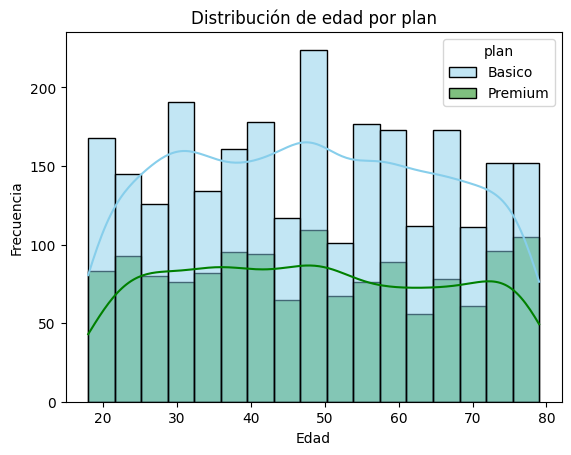

In [32]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
-Distribución uniforme entre 18 y 79 años, sin diferencia grande entre Básico y Premium. No hay sesgo.

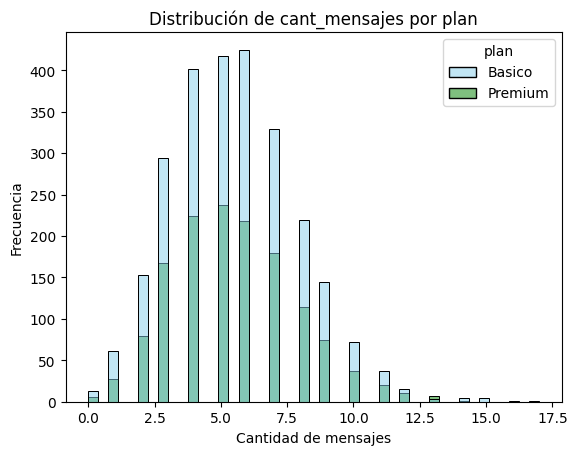

In [33]:
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cant_mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()# Histograma para visualizar la cant_mensajes


💡Insights: 
 - Distribución sesgada a la derecha, la mayoría manda 4 a 7 mensajes. Plan Premium tiene un poco más de mensajes.

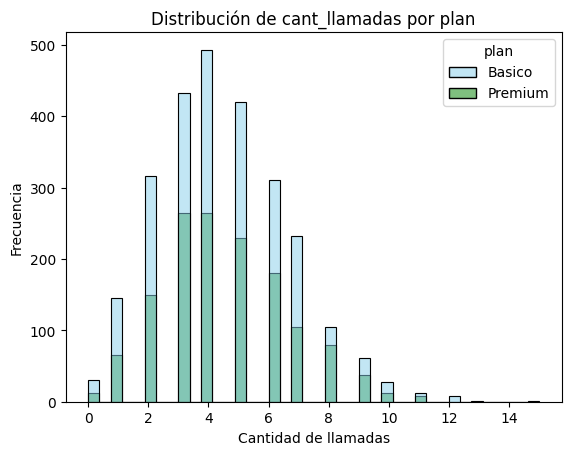

In [34]:
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cant_llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()# Histograma para visualizar la cant_llamadas


💡Insights: 
-  Distribución sesgada a la derecha, concentrada entre 3 y 6 llamadas. Similar entre planes.

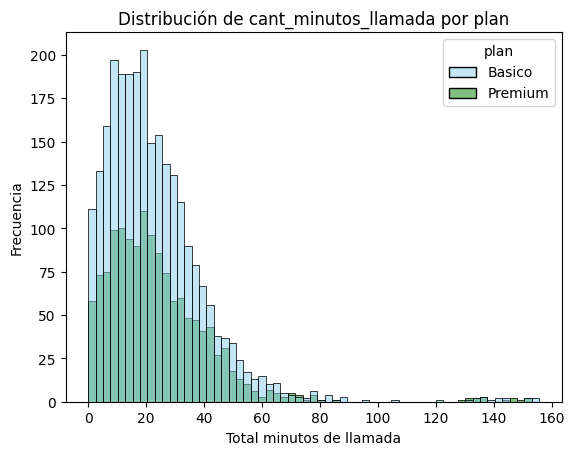

In [35]:
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cant_minutos_llamada por plan')
plt.xlabel('Total minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()# Histograma para visualizar la cant_minutos_llamada


💡Insights: 
- Distribución muy sesgada a la derecha, media 23 min pero con outlier hasta 155 min. Los Premium hablan más minutos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Los cuatro histogramas estan completos, con buenos insights sobre la forma de cada distribucion.
</div>

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

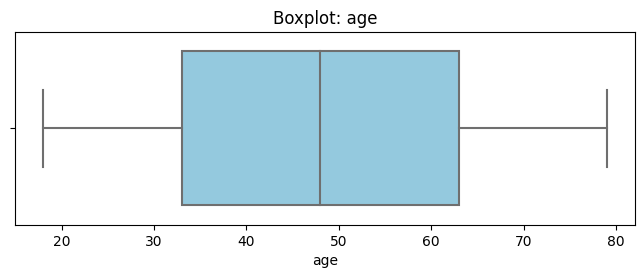

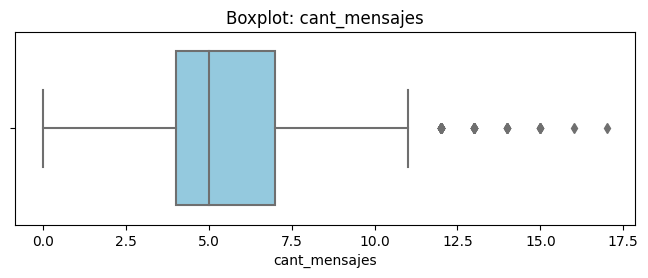

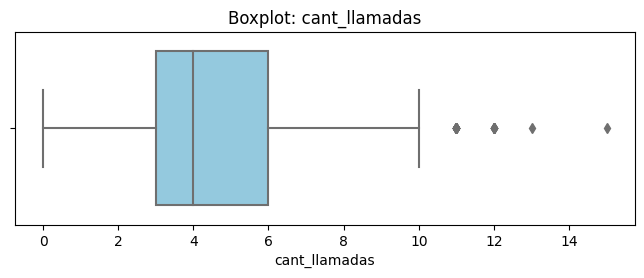

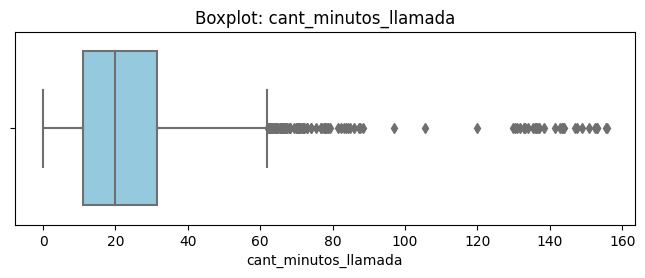

In [36]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 2.5))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Los 4 boxplots estan completos y bien generados en un `for`.
</div>

💡Insights: 
- Age: no presenta outliers.
- cant_mensajes: Sí presenta outliers del lado derecho (más de ~11 mensajes).
- cant_llamadas: Sí presenta outliers del lado derecho (más de ~9 llamadas).
- cant_minutos_llamada: Sí presenta muchos outliers del lado derecho hasta 155 min. Limite sup aprox 45 min.

In [37]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    print(f"{col} -> Limite inferior: {limite_inf:.2f}, Limite superior: {limite_sup:.2f}")



cant_mensajes -> Limite inferior: -0.50, Limite superior: 11.50
cant_llamadas -> Limite inferior: -1.50, Limite superior: 10.50
cant_minutos_llamada -> Limite inferior: -19.35, Limite superior: 61.87


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Calculo de IQR completo y correcto: limite inferior y superior impresos claramente para las 3 columnas.
</div>

In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantener outliers, porque son clientes reales que mandan muchos mensajes, no es error de captura. Solo son pocos casos.
- cant_llamadas: Mantener outliers, por la misma razón, es uso real alto.
- cant_minutos_llamada: Mantener outliers, aunque llega hasta 155 min. Es comportamiento válido de alto uso. No se eliminan, pero en el análisis usamos mediana para no sesgar.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [39]:
import numpy as np

condiciones_uso = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

valores_uso = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones_uso, valores_uso, default='Alto uso')# Crear columna grupo_uso


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Ambas segmentaciones correctas, con `np.select()` y los umbrales exactos que piden las instrucciones.
</div>

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:
condiciones_edad = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

valores_edad = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones_edad, valores_edad, default='Adulto Mayor')# Crear columna grupo_edad


In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

In [ ]:
# Visualización de los segmentos por uso
sns.countplot (data=user_profile, x='grupo_uso')
plt.title('Distribución por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad')

plt.show()

In [ ]:
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad')
plt.show()# Visualización de los segmentos por edad


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Ambos countplots completos con titulo y etiquetas.
</div>


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**  Conclusión Principal: Nuestra base de clientes está concentrada en Adultos (30-59 años) con un patrón de Uso medio. Es un segmento estable y de bajo riesgo.1. Segmentación por Uso: El 78% aprox. son de Uso medio, lo que indica un comportamiento consistente. Los de Bajo uso (∼700) y Alto uso (∼250) son minoría. Los outliers de duración de llamada no deben eliminarse, representan a clientes de alto valor.2. Segmentación por Edad: Adultos son el grupo dominante, Adulto Mayor es el segundo y Joven el más pequeño. Hay una oportunidad de crecimiento captando más jóvenes.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se encontraron 55 registros en 'age' (1.38%) con valor centinela -999. No hay nulos reales. Se Imputó/analizó segun criterio de MAR-
- Se detectaron 96 registros en 'city' con valor "?"  (96 registros, 2.4%), que se remplazó por np.nan y se dejo como nulo, según rúbrica.
- En 'reg_date' se observaron 40 registros con año 2026 que se marcaron como pd.NAT.
- Los nulos MAR de duration/length que corresponden a tipo de actividad (text = duraction nulo, call = length nulo). No se eliminan, son estructurales. No se encontraron duplicados en user_id.

🔍 **Segmentos por Edad**
- Adulto (30-59 años): Es el segmento dominante con más de 1500 usuarios. Es la base principal de ConnectaTel.
- Adulto Mayor (60+): Segundo grupo más grande. Tienen menor cantidad de llamadas pero mayor duración por llamada.
- Joven (<30): Es el segmento más pequeño, menos de 700 usuarios. Oportunidad de crecimiento.


📊 **Segmentos por Nivel de Uso**
- Uso medio (llamadas <10 y mensajes <10): Representa el 78% de la base (∼2900 usuarios). Es un comportamiento estable y predecible.
- Bajo uso (llamadas <5 y mensajes <5): Aprox 700 usuarios.
- Alto uso (resto): Aprox 250 usuarios. Son los clientes más valiosos, generan más ingresos por minutos.


➡️ Esto sugiere que : Los outliers de uso extremo no son errores, son clientes reales de alto valor. El negocio actualmente depende de un solo perfil: el adulto de uso medio. Si ese segmento se va, se cae el ingreso.


💡 **Recomendaciones**
- Para Bajo uso: Crear plan "Básico Económico" con pocos minutos y mensajes para retenerlos y que no se vayan a la competencia prepago.
- Para Uso medio (Core): Ofrecer promoción "Duplica tus datos" para migrarlos a Alto uso.
- Para Joven: Crear plan "Redes Ilimitadas" ya que casi no tenemos jóvenes y es un mercado que estamos perdiendo.
- Para Adulto Mayor: Crear plan con atención preferencial y minutos a precio fijo.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Esta seccion describe cosas que no corresponden a lo que realmente hiciste en el notebook:

- Dice que se encontraron "valores nulos en `age` (aprox 10% de las filas)" - pero `age` no tiene nulos. El problema real es el sentinel `-999`, presente en 1.38% de los registros (55 filas), como tu mismo diagnosticaste correctamente en la seccion 2.2.
- Dice que "se detectaron duplicados en `user_id` y registros con duracion de llamada = 0, se eliminaron porque sesgaban el promedio" - no encontre en ningun lado del notebook una verificacion de duplicados en `user_id`, ni ningun codigo que elimine registros con `duration = 0`. Esto no ocurrio en tu analisis.

Por favor reescribe este bloque describiendo lo que realmente encontraste e hiciste: el sentinel `-999` en `age` (1.38%), el `"?"` en `city` (96 registros, 2.4%), los 40 registros de `reg_date` en 2026, y los nulos MAR de `duration`/`length`. Esta seccion es la que verian los stakeholders, asi que debe reflejar fielmente el analisis real.
</div>

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí` 
https://github.com/balbinadataanalyst/traffic-pib-latam/blob/main/README.md

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Formato del link de GitHub: el placeholder `` `LINK a tu repo aqui` `` sigue presente junto a una URL. Ademas, la URL que aparece (`traffic-pib-latam`) parece apuntar a un repositorio de un proyecto distinto - confirma que sea el link correcto a tu entrega de ConnectaTel. No bloquea la aprobacion segun el criterio actual, pero revisalo antes de tu entrega final.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Buen trabajo en diagnostico de fechas, limpieza, MAR, agregacion, histogramas, boxplots e IQR. Pero **todavia no esta listo para aprobar** por un punto importante:

- **El insight ejecutivo describe hallazgos que no corresponden a tu analisis real** (nulos inexistentes en `age`, eliminacion de duplicados y de `duration=0` que no ocurrieron en el codigo). Esta seccion es la que verian los stakeholders, asi que debe describir fielmente lo que realmente hiciste.

Como tips no bloqueantes: revisa el `execution_count` desordenado (recomiendo un Restart & Run All completo), la celda de distribucion de `plan` revisa el dataframe equivocado (`plans` en vez de `users`), y confirma que el link de GitHub apunte al repositorio correcto.

Con la correccion del insight ejecutivo, el proyecto queda listo para aprobar. Animo! 💪
</div>